# 04 – CardioGNN Training Pipeline (v5)

## Diagnosis of v4 regression

v4 fixed the training bugs from v3 and improved F2 (0.154→0.330) and
Brier (0.513→0.322), but one structural problem remained:

| Observation                                     | Root cause                                                                 | Impact                                                                       |
|:-----------------------|:-----------------------|:-----------------------|
| Best val AUROC was **epoch 1** — never improved | Only 20 val positives; AUROC is too noisy to be a reliable stopping signal | Model trained for 51 epochs selecting a checkpoint equivalent to random init |
| Train AUROC 0.75 vs Val AUROC 0.62              | 94k-param model with 116 training positives — severely over-parameterised  | Large train-val gap, poor generalisation                                     |
| Val AUROC 0.62 with patience=50                 | Noisy signal causes premature stopping or wrong checkpoint selection       | Irreproducible results across runs                                           |

## Fixes in v5

| \#  | Problem                                                     | Fix                                                                                                                                        |
|:-----------------------|:-----------------------|:-----------------------|
| 1   | **20 val positives** — too noisy for any stopping criterion | **Stratified 5-fold CV**: each fold has ~27 val positives (35% more); OOF predictions pool all 1631 patients for reliable metric estimates |
| 2   | **94k params / 116 train positives** — severe overfitting   | **Smaller model**: HIDDEN_DIM 64→48, GAT_LAYERS 3→2; ~57k params                                                                           |
| 3   | **Single model** sensitive to bad checkpoint selection      | **Ensemble**: 5 models trained on different splits; test predictions averaged                                                              |
| 4   | **Temperature scaling on 20 val positives** — unreliable    | Temperature scaled on **all OOF predictions** (~1631 samples, ~135 positives)                                                              |
| 5   | **DROPOUT=0.30** insufficient for model size                | DROPOUT 0.30→0.40, WEIGHT_DECAY 1e-4→5e-4                                                                                                  |
| 6   | **LR 5e-4 too high** for smaller model                      | LR 5e-4→3e-4                                                                                                                               |

## Design: Stratified K-Fold + Ensemble

    idx_trval (85%)  ──→  5-Fold CV  ──→  5 models trained
                                           OOF preds pooled (all ~1631 patients)
                                           Test preds averaged  ──→  ensemble score
    idx_test  (15%)  ──→  each fold predicts  ──→  average  ──→  final evaluation

The **best single fold model** (by OOF AUROC) is saved for
`05_explainability.ipynb`. The ensemble is used for final reporting.

## Explainability hooks (unchanged from v4)

-   `OntologyEncoder.forward(return_attn=True)` — per-layer GAT attention
-   `CardioGNN.explain_forward(...)` — `(logit, node_emb, attn_layers, event_weights)`
-   `x_override` in all GAT layers
-   `event_weights` from SequenceAttention

## 1. Imports

In [1]:
import pickle
import random
import math
import warnings
from pathlib import Path
from dataclasses import dataclass
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.swa_utils import AveragedModel

from torch_geometric.nn import GATv2Conv

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    fbeta_score, f1_score, classification_report,
    roc_curve, precision_recall_curve,
    precision_score, recall_score,
    confusion_matrix, brier_score_loss,
)

warnings.filterwarnings("ignore", category=UserWarning)

c:\Users\marti\Desktop\ST-GNN-Comp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [2]:
@dataclass
class Config:
    # ── Paths ───────────────────────────────────────────────────────────
    GRAPH_PATH  : str = r"data/processed/ontology_graph.pkl"
    COHORT_PATH : str = r"data/processed/omop_cohort.pkl"
    OUTPUT_DIR  : str = "outputs"

    # ── Target ──────────────────────────────────────────────────────────
    TARGET_CONCEPT_ID   : int = 4329847
    TARGET_CONCEPT_NAME : str = "Myocardial infarction"

    # ── Embeddings ──────────────────────────────────────────────────────
    EMBED_MODEL : str = "pritamdeka/S-PubMedBert-MS-MARCO"

    # ── Architecture ────────────────────────────────────────────────────
    HIDDEN_DIM     : int   = 56      # compromise: 48 over-regularised, 64 overfit
    GAT_LAYERS     : int   = 2       # FIX: 3→2 — sufficient depth, less capacity
    GAT_HEADS      : int   = 4       # 48/4 = 12 dims per head
    DEMO_DIM       : int   = 0
    DROPOUT        : float = 0.35    # FIX: 0.40 crushed signal; 0.35 is sufficient
    TIME2VEC_K     : int   = 8
    SEQ_ATTN_HEADS : int   = 4

    # ── Cross-validation ────────────────────────────────────────────────
    N_FOLDS      : int   = 5         # NEW: stratified k-fold
    TEST_SIZE    : float = 0.15      # held-out test set (never seen during CV)

    # ── Training (per fold) ─────────────────────────────────────────────
    SEED         : int   = 42
    EPOCHS       : int   = 200       # cosine cycles handle this gracefully
    BATCH_SIZE   : int   = 32
    LR           : float = 4e-4      # slight increase; lighter regularisation needs it
    PATIENCE     : int   = 40
    WEIGHT_DECAY : float = 2e-4      # FIX: 5e-4 too aggressive, compressed probs to 0.5

    # ── LR schedule ─────────────────────────────────────────────────────
    T0_EPOCHS    : int   = 20        # shorter cycle for smaller model
    T_MULT       : int   = 2

    # ── Class imbalance ─────────────────────────────────────────────────
    USE_FOCAL_LOSS       : bool  = True
    FOCAL_GAMMA          : float = 2.0
    USE_POS_WEIGHT       : bool  = True
    USE_BALANCED_SAMPLER : bool  = True
    POS_WEIGHT_BALANCED  : float = 2.0   # v5: balanced sampler already creates 50/50 batches
    LABEL_SMOOTHING      : float = 0.05

    # ── Augmentation ────────────────────────────────────────────────────
    CONCEPT_DROPOUT  : float = 0.10
    TIME_JITTER_STD  : float = 0.02

    # ── SWA ─────────────────────────────────────────────────────────────
    USE_SWA         : bool  = True
    SWA_START_EPOCH : int   = 15     # earlier start for shorter folds

    # ── Calibration ─────────────────────────────────────────────────────
    CALIBRATE_TEMP  : bool  = True

    # ── Stopping metric ─────────────────────────────────────────────────
    STOP_ON_AUROC   : bool  = True

    # ── Threshold ───────────────────────────────────────────────────────
    RECALL_FLOOR       : float = 0.70    # NEW: min recall for clinical screening
    THRESHOLD_FALLBACK : float = 0.50

    # ── Sequence ────────────────────────────────────────────────────────
    MAX_SEQ_LEN : int = 50


cfg    = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(s: int):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True


set_seed(cfg.SEED)

PLOTS_DIR = Path(cfg.OUTPUT_DIR) / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

if not hasattr(plt, "_original_show"):
    plt._original_show = plt.show
    plt._plot_counter   = 0

def _save_then_show(*args, **kwargs):
    for n in plt.get_fignums():
        plt._plot_counter += 1
        plt.figure(n).savefig(
            PLOTS_DIR / f"plot_{plt._plot_counter:03d}.png",
            dpi=220, bbox_inches="tight",
        )
    return plt._original_show(*args, **kwargs)

plt.show = _save_then_show

print(f"Device  : {DEVICE}")
print(f"Plots → : {PLOTS_DIR.resolve()}")

Device  : cuda
Plots → : C:\Users\marti\Desktop\ST-GNN-Comp\outputs\plots


## 3. Data and Ontology Graph

In [3]:
print("Loading data...")

with open(cfg.GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

with open(cfg.COHORT_PATH, "rb") as f:
    cohort = pickle.load(f)

nodes        = sorted(G.nodes())
concept2idx  = {c: i for i, c in enumerate(nodes)}
idx2concept  = {i: c for c, i in concept2idx.items()}
NUM_CONCEPTS = len(concept2idx)
PAD_IDX      = NUM_CONCEPTS

id2name = (
    cohort[["concept_id", "concept_name"]]
    .drop_duplicates()
    .set_index("concept_id")["concept_name"]
    .to_dict()
)
_OMOP_EXTRA = {
    73553:    "Rheumatoid arthritis",     77670:    "Chest pain",
    316139:   "Heart failure",            374009:   "Hypertensive disorder",
    443392:   "Atherosclerosis",          443432:   "Coronary arteriosclerosis",
    4092747:  "Acute myocardial infarction",
    4115408:  "Unstable angina",          4140090:  "Tremor",
    4166245:  "Cerebral infarction",      4168666:  "Cerebrovascular disease",
    4176946:  "Degenerative joint disease",
    4181063:  "Vascular dementia",        4182007:  "Senile dementia",
    4185932:  "Ischemic heart disease",   4274025:  "Type 2 diabetes mellitus",
    4301371:  "Akinesia",                 4354249:  "Non-ST elevation MI",
    41901029: "Malignant neoplasm of bronchus",
}
id2name = {**_OMOP_EXTRA, **id2name}

src, dst = [], []
for u, v in G.edges():
    src += [concept2idx[u], concept2idx[v]]
    dst += [concept2idx[v], concept2idx[u]]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long).to(DEVICE)

print(f"Graph nodes : {NUM_CONCEPTS:,}")
print(f"Total edges : {EDGE_INDEX.shape[1]:,}  (bidirectional)")
print(f"PAD index   : {PAD_IDX}")

Loading data...
Graph nodes : 29
Total edges : 42  (bidirectional)
PAD index   : 29


## 4. Biomedical Node Embeddings

In [4]:
print(f"Generating embeddings with '{cfg.EMBED_MODEL}'...")

concept_names = [
    id2name.get(idx2concept[i], str(idx2concept[i]))
    for i in range(NUM_CONCEPTS)
]

embedder = SentenceTransformer(cfg.EMBED_MODEL)
_raw = embedder.encode(
    concept_names, convert_to_tensor=True,
    show_progress_bar=False, device=str(DEVICE),
)
CONCEPT_EMBEDDINGS_RAW = _raw.float().to(DEVICE)
EMBED_DIM = CONCEPT_EMBEDDINGS_RAW.shape[1]

print(f"Embedding dimension : {EMBED_DIM}")
print(f"Embedding shape     : {CONCEPT_EMBEDDINGS_RAW.shape}")

Generating embeddings with 'pritamdeka/S-PubMedBert-MS-MARCO'...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 64027.81it/s]
BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension : 768
Embedding shape     : torch.Size([29, 768])


## 5. Patient Sequence Construction

In [5]:
print("Building patient trajectories...")

known_ids = set(concept2idx.keys())
df = cohort[cohort["concept_id"].isin(known_ids)].copy()
df["node_idx"] = df["concept_id"].map(concept2idx).astype(int)
df = df.sort_values(["idauniq", "interview_date", "node_idx"])

MAX_DAYS = float(df["time_delta"].max())


def log_norm_time(x: float) -> float:
    return math.log1p(x) / math.log1p(MAX_DAYS + 1e-6)


all_c, all_t, all_l, all_y = [], [], [], []
excluded_prior_target = 0

for pid in df["idauniq"].unique():
    p = (
        df[df["idauniq"] == pid]
        .sort_values(["interview_date", "node_idx"])
        .drop_duplicates(subset=["node_idx", "interview_date"])
    )
    dates = np.sort(p["interview_date"].unique())
    if len(dates) < 2:
        continue

    last_date = dates[-1]
    history_p = p[p["interview_date"] < last_date]
    future_p  = p[p["interview_date"] == last_date]

    if history_p.empty:
        continue

    if cfg.TARGET_CONCEPT_ID in history_p["concept_id"].values:
        excluded_prior_target += 1
        continue

    label   = float(cfg.TARGET_CONCEPT_ID in future_p["concept_id"].values)
    seq_len = min(len(history_p), cfg.MAX_SEQ_LEN)
    h       = history_p.iloc[-seq_len:]

    pad_len = cfg.MAX_SEQ_LEN - seq_len
    c = [PAD_IDX] * pad_len + h["node_idx"].tolist()
    t = [0.0]     * pad_len + [log_norm_time(v) for v in h["time_delta"].tolist()]

    all_c.append(c); all_t.append(t)
    all_l.append(seq_len); all_y.append(label)

C = np.array(all_c, dtype=np.int32)
T = np.array(all_t, dtype=np.float32)
L = np.array(all_l, dtype=np.int32)
Y = np.array(all_y, dtype=np.float32)

pos = Y.sum(); neg = len(Y) - pos
print(f"Total patients          : {len(Y):,}")
print(f"Excluded (prior MI)     : {excluded_prior_target:,}")
print(f"Positive (MI next visit): {int(pos):,}  ({100*pos/len(Y):.1f}%)")
print(f"Negative                : {int(neg):,}")

Building patient trajectories...
Total patients          : 1,919
Excluded (prior MI)     : 325
Positive (MI next visit): 160  (8.3%)
Negative                : 1,759


## 6. Train / Test Split + Dataset

The 15% test set is carved out first and **never touched during CV**.
The remaining 85% (`idx_trval`) is split into 5 folds by `StratifiedKFold`.

Each fold sees approximately:
- Train: ~1306 patients, ~109 positives
- Val: ~326 patients, ~27 positives ← 35% more than v4’s 20

In [6]:
all_idx = np.arange(len(Y))
idx_trval, idx_test = train_test_split(
    all_idx, test_size=cfg.TEST_SIZE, stratify=Y, random_state=cfg.SEED
)

print(f"Test set  : {len(idx_test):,} patients  "
      f"({int(Y[idx_test].sum())} positive, {100*Y[idx_test].mean():.1f}%)")
print(f"CV pool   : {len(idx_trval):,} patients  "
      f"({int(Y[idx_trval].sum())} positive, {100*Y[idx_trval].mean():.1f}%)")
print(f"\nStratified {cfg.N_FOLDS}-fold CV — approx per fold:")
n_val = len(idx_trval) // cfg.N_FOLDS
print(f"  Train : ~{len(idx_trval) - n_val:,}  Val : ~{n_val:,} "
      f"(~{int(Y[idx_trval].mean() * n_val)} positives per val fold)")


class PatientDataset(Dataset):
    def __init__(self, c, t, l, y, augment=False):
        self.c        = torch.tensor(c, dtype=torch.long)
        self.t        = torch.tensor(t, dtype=torch.float32)
        self.l        = torch.tensor(l, dtype=torch.long)
        self.y        = torch.tensor(y, dtype=torch.float32)
        self.pad_mask = (self.c == PAD_IDX)
        self.augment  = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        c_i  = self.c[i].clone()
        t_i  = self.t[i].clone()
        pm_i = self.pad_mask[i].clone()

        if self.augment:
            if cfg.CONCEPT_DROPOUT > 0:
                real_mask = ~pm_i
                drop_mask = (torch.rand_like(real_mask.float()) < cfg.CONCEPT_DROPOUT) & real_mask
                c_i[drop_mask] = PAD_IDX
                pm_i = (c_i == PAD_IDX)
            if cfg.TIME_JITTER_STD > 0:
                t_i = (t_i + torch.randn_like(t_i) * cfg.TIME_JITTER_STD).clamp(min=0.0)

        demo_i = torch.zeros(max(cfg.DEMO_DIM, 1), dtype=torch.float32)
        return c_i, t_i, self.l[i], pm_i, demo_i, self.y[i]


def make_loader(indices, shuffle: bool, augment: bool = False) -> DataLoader:
    ds = PatientDataset(C[indices], T[indices], L[indices], Y[indices], augment=augment)
    sampler = None
    if shuffle and cfg.USE_BALANCED_SAMPLER:
        labels       = Y[indices]
        class_counts = np.bincount(labels.astype(int))
        weights      = 1.0 / class_counts[labels.astype(int)]
        sampler      = WeightedRandomSampler(weights, len(weights), replacement=True)
        shuffle      = False
    return DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=shuffle,
                      sampler=sampler, pin_memory=DEVICE.type == "cuda",
                      drop_last=False)


# Test loader is fixed across all folds
test_loader = make_loader(idx_test, shuffle=False, augment=False)

Test set  : 288 patients  (24 positive, 8.3%)
CV pool   : 1,631 patients  (136 positive, 8.3%)

Stratified 5-fold CV — approx per fold:
  Train : ~1,305  Val : ~326 (~27 positives per val fold)


## 7. Model Architecture – CardioGNN v5

Architecture is identical to v4 but with HIDDEN_DIM=48, GAT_LAYERS=2,
DROPOUT=0.40. Parameter count drops from 94k to ~57k, matching the
dataset size better.

In [7]:
class Time2Vec(nn.Module):
    """Learnable multi-frequency time encoding. Kazemi et al. 2019."""
    def __init__(self, hidden_dim: int, k_periodic: int = 8):
        super().__init__()
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, k_periodic)
        self.proj     = nn.Linear(1 + k_periodic, hidden_dim)

    def forward(self, time_seqs: torch.Tensor) -> torch.Tensor:
        t = time_seqs.unsqueeze(-1)
        return self.proj(torch.cat([self.linear(t), torch.sin(self.periodic(t))], dim=-1))


class SequenceAttention(nn.Module):
    """
    CLS-query attentive pooling over patient event sequence.
    event_weights → [B, T] directly used for explainability.
    NaN guard: fully-masked rows (extreme concept dropout) fall back
    to unmasked attention so softmax never sees all -inf inputs.
    """
    def __init__(self, hidden_dim: int, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=n_heads,
            dropout=dropout, batch_first=True,
        )
        self.query = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.norm  = nn.LayerNorm(hidden_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor):
        B = x.shape[0]
        q = self.query.expand(B, -1, -1)

        # NaN guard: if all positions are masked, unmask that row
        all_masked = pad_mask.all(dim=1)
        safe_mask  = pad_mask.clone()
        if all_masked.any():
            safe_mask[all_masked] = False

        attended, attn_weights = self.attn(
            q, x, x,
            key_padding_mask=safe_mask,
            need_weights=True,
            average_attn_weights=True,
        )
        out = self.norm(self.drop(attended.squeeze(1)))
        return out, attn_weights.squeeze(1)


class OntologyEncoder(nn.Module):
    """N-layer GATv2 with residual connections. x_override for GNNExplainer."""
    def __init__(self, raw_embeddings, embed_dim, hidden_dim, heads, n_layers, dropout):
        super().__init__()
        self.register_buffer("raw_embed", raw_embeddings.detach().clone())
        self.proj  = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.drop  = nn.Dropout(dropout)
        dim_per_head = hidden_dim // heads
        self.convs = nn.ModuleList([
            GATv2Conv(hidden_dim, dim_per_head, heads=heads,
                      dropout=dropout, add_self_loops=True)
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(n_layers)])

    def forward(self, edge_index, return_attn=False, x_override=None):
        x = F.gelu(self.proj(x_override if x_override is not None else self.raw_embed))
        attn_list = []
        for conv, norm in zip(self.convs, self.norms):
            if return_attn:
                out, (ei, a) = conv(x, edge_index, return_attention_weights=True)
                attn_list.append((ei, a))
            else:
                out = conv(x, edge_index)
            x = norm(self.drop(F.gelu(out)) + x)
        return (x, attn_list) if return_attn else x


class CardioGNN(nn.Module):
    """CardioGNN v5 — smaller (HIDDEN_DIM=48, GAT_LAYERS=2), more regularised."""
    def __init__(self, raw_embeddings, embed_dim, hidden_dim,
                 gat_heads, gat_layers, dropout, time2vec_k=8, seq_attn_heads=4):
        super().__init__()
        self.ontology_enc = OntologyEncoder(raw_embeddings, embed_dim, hidden_dim,
                                             gat_heads, gat_layers, dropout)
        self.time_enc  = Time2Vec(hidden_dim, k_periodic=time2vec_k)
        self.seq_attn  = SequenceAttention(hidden_dim, n_heads=seq_attn_heads, dropout=dropout)
        self.drop      = nn.Dropout(dropout)
        in_dim = hidden_dim + (cfg.DEMO_DIM if cfg.DEMO_DIM > 0 else 0)
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def _encode_and_pool(self, edge_index, concept_seqs, time_seqs,
                          pad_mask, return_attn=False, x_override=None):
        if return_attn:
            node_emb, attn_layers = self.ontology_enc(edge_index, return_attn=True,
                                                        x_override=x_override)
        else:
            node_emb    = self.ontology_enc(edge_index, x_override=x_override)
            attn_layers = None
        safe_seqs    = concept_seqs.clamp(max=node_emb.shape[0] - 1)
        x            = node_emb[safe_seqs] + self.time_enc(time_seqs)
        patient_rep, event_weights = self.seq_attn(x, pad_mask)
        return self.drop(patient_rep), node_emb, attn_layers, event_weights

    def forward(self, edge_index, concept_seqs, time_seqs,
                seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, _, _, _ = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1)

    def explain_forward(self, edge_index, concept_seqs, time_seqs,
                        seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, node_emb, attn_layers, event_weights = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask,
            return_attn=True, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1), node_emb, attn_layers, event_weights


def build_model():
    return CardioGNN(
        CONCEPT_EMBEDDINGS_RAW, EMBED_DIM,
        cfg.HIDDEN_DIM, cfg.GAT_HEADS, cfg.GAT_LAYERS, cfg.DROPOUT,
        time2vec_k=cfg.TIME2VEC_K, seq_attn_heads=cfg.SEQ_ATTN_HEADS,
    ).to(DEVICE)


# Show parameter count
_tmp = build_model()
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}  (v4 was 94,483)")
for name, mod in _tmp.named_children():
    n = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    print(f"  {name:<20}: {n:,}")
del _tmp

Trainable parameters : 71,363  (v4 was 94,483)
  ontology_enc        : 56,224
  time_enc            : 578
  seq_attn            : 12,936
  drop                : 0
  head                : 1,625


## 8. Loss Function

In [8]:
# pos_weight: mild boost (2.0) since balanced sampler creates ~50/50 batches
pos_weight = (torch.tensor([cfg.POS_WEIGHT_BALANCED], dtype=torch.float).to(DEVICE)
              if cfg.USE_POS_WEIGHT else None)

print(f"pos_weight      : {pos_weight.item() if pos_weight is not None else 'disabled'}")
print(f"  (raw class ratio in train: ~{int((1-Y[idx_trval].mean())/Y[idx_trval].mean()):.0f}:1, "
      f"overridden because balanced sampler active)")
print(f"Focal gamma     : {cfg.FOCAL_GAMMA}")
print(f"Label smoothing : {cfg.LABEL_SMOOTHING}")


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma           = gamma
        self.pos_weight      = pos_weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        bce  = F.binary_cross_entropy_with_logits(inputs, targets,
                                                    pos_weight=self.pos_weight,
                                                    reduction="none")
        loss = (1 - torch.exp(-bce)) ** self.gamma * bce
        return loss.mean()


criterion = FocalLoss(gamma=cfg.FOCAL_GAMMA, pos_weight=pos_weight,
                       label_smoothing=cfg.LABEL_SMOOTHING)

pos_weight      : 2.0
  (raw class ratio in train: ~10:1, overridden because balanced sampler active)
Focal gamma     : 2.0
Label smoothing : 0.05


## 9. Per-Fold Training Function

`run_fold` is self-contained: it initialises a fresh model, trains it,
and returns predictions on both the val fold and the fixed test set.

Using a function rather than inline code makes the fold loop clean and
ensures no state leaks between folds.

In [9]:
def find_best_threshold(truths, preds, beta=1.0, recall_floor=0.0):
    """Maximise F-beta subject to recall >= recall_floor."""
    _, _, thresholds = roc_curve(truths, preds)
    best_score, best_thr = 0.0, cfg.THRESHOLD_FALLBACK
    b2 = beta ** 2
    for thr in thresholds:
        bp = (preds >= thr).astype(int)
        p  = precision_score(truths.astype(int), bp, zero_division=0)
        r  = recall_score(truths.astype(int),    bp, zero_division=0)
        if r < recall_floor:
            continue
        if p + r == 0:
            continue
        score = (1 + b2) * p * r / (b2 * p + r)
        if score > best_score:
            best_score, best_thr = score, thr
    return float(best_thr)


def run_fold(fold_idx: int,
             idx_tr_fold: np.ndarray,
             idx_val_fold: np.ndarray) -> dict:
    """
    Train one fold. Returns dict with:
      model_state   : best checkpoint state_dict
      val_preds     : sigmoid predictions on val fold  [N_val]
      val_truths    : labels for val fold              [N_val]
      val_auroc     : best val AUROC achieved
      val_auprc     : val AUPRC at best checkpoint
      test_preds    : sigmoid predictions on test set  [N_test]
      history       : list of per-epoch dicts
    """
    set_seed(cfg.SEED + fold_idx)   # deterministic but different per fold

    # ── Loaders ──────────────────────────────────────────────────────────
    tr_loader  = make_loader(idx_tr_fold,  shuffle=True,  augment=True)
    val_loader = make_loader(idx_val_fold, shuffle=False, augment=False)

    # ── Fresh model + optimiser ──────────────────────────────────────────
    model     = build_model()
    optimizer = AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=cfg.T0_EPOCHS,
                                             T_mult=cfg.T_MULT, eta_min=1e-6)
    swa_model = AveragedModel(model) if cfg.USE_SWA else None

    # ── Inner helpers ─────────────────────────────────────────────────────
    def train_epoch():
        model.train()
        total_loss, preds, truths = 0.0, [], []
        for c_s, t_s, lens, p_mask, demo, lbl in tr_loader:
            c_s    = c_s.to(DEVICE);    t_s   = t_s.to(DEVICE)
            lens   = lens.to(DEVICE);   lbl   = lbl.to(DEVICE)
            p_mask = p_mask.to(DEVICE); demo  = demo.to(DEVICE)
            optimizer.zero_grad()
            logits = model(EDGE_INDEX, c_s, t_s, lens, p_mask, demo)
            loss   = criterion(logits, lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(lbl)
            preds.extend(torch.sigmoid(logits).detach().cpu().tolist())
            truths.extend(lbl.cpu().tolist())
        auroc = roc_auc_score(truths, preds) if len(set(truths)) > 1 else 0.0
        return total_loss / len(tr_loader.dataset), auroc

    @torch.no_grad()
    def evaluate_loader(loader, eval_model=None):
        m = eval_model if eval_model is not None else model
        m.eval()
        total_loss, preds, truths = 0.0, [], []
        for c_s, t_s, lens, p_mask, demo, lbl in loader:
            c_s    = c_s.to(DEVICE);    t_s   = t_s.to(DEVICE)
            lens   = lens.to(DEVICE);   lbl   = lbl.to(DEVICE)
            p_mask = p_mask.to(DEVICE); demo  = demo.to(DEVICE)
            logits = m(EDGE_INDEX, c_s, t_s, lens, p_mask, demo)
            total_loss += criterion(logits, lbl).item() * len(lbl)
            preds.extend(torch.sigmoid(logits).cpu().tolist())
            truths.extend(lbl.cpu().tolist())
        p_arr = np.array(preds); t_arr = np.array(truths)
        auroc = roc_auc_score(t_arr, p_arr)           if len(set(truths)) > 1 else 0.0
        auprc = average_precision_score(t_arr, p_arr) if len(set(truths)) > 1 else 0.0
        brier = brier_score_loss(t_arr, p_arr)
        return total_loss / len(loader.dataset), auroc, auprc, brier, p_arr, t_arr

    # ── Training loop ────────────────────────────────────────────────────
    best_metric, best_weights, patience_cnt = 0.0, None, 0
    swa_active = False
    history    = []

    for epoch in range(1, cfg.EPOCHS + 1):
        tr_loss, tr_auroc = train_epoch()
        vl_loss, vl_auroc, vl_auprc, vl_brier, _, _ = evaluate_loader(val_loader)
        scheduler.step(epoch - 1)

        if cfg.USE_SWA and epoch >= cfg.SWA_START_EPOCH:
            swa_active = True
            swa_model.update_parameters(model)

        stop_val = vl_auroc if cfg.STOP_ON_AUROC else vl_auprc
        history.append(dict(epoch=epoch, tr_loss=tr_loss, vl_loss=vl_loss,
                             tr_auroc=tr_auroc, vl_auroc=vl_auroc,
                             vl_auprc=vl_auprc, vl_brier=vl_brier,
                             lr=optimizer.param_groups[0]["lr"]))

        if stop_val > best_metric + 1e-4:
            best_metric  = stop_val
            patience_cnt = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= cfg.PATIENCE:
                break

    # ── Select weights: SWA vs best checkpoint ───────────────────────────
    if swa_active:
        torch.optim.swa_utils.update_bn(tr_loader, swa_model, device=DEVICE)
        _, swa_auroc, _, _, _, _ = evaluate_loader(val_loader, eval_model=swa_model)
        swa_stop = swa_auroc if cfg.STOP_ON_AUROC else swa_auroc
        if swa_stop > best_metric:
            swa_sd = {k.replace("module.", ""): v
                      for k, v in swa_model.state_dict().items()
                      if k.startswith("module.")}
            model.load_state_dict(swa_sd, strict=False)
            best_metric = swa_stop
        else:
            model.load_state_dict(best_weights, strict=False)
    else:
        model.load_state_dict(best_weights, strict=False)

    # ── Final predictions + per-fold temperature scaling ────────────────
    # FIX: calibrate each fold on its own val set before contributing to
    # ensemble. Without this, folds with compressed probability scales
    # drag the ensemble average down, inflating the threshold.
    model.eval()
    val_logits_list, val_preds_list, val_truths_list = [], [], []
    test_logits_list, test_preds_list, test_truths_list = [], [], []

    with torch.no_grad():
        for c_s, t_s, lens, p_mask, demo, lbl in val_loader:
            c_s = c_s.to(DEVICE); t_s = t_s.to(DEVICE)
            lens = lens.to(DEVICE); p_mask = p_mask.to(DEVICE); demo = demo.to(DEVICE)
            logits = model(EDGE_INDEX, c_s, t_s, lens, p_mask, demo)
            val_logits_list.extend(logits.cpu().tolist())
            val_preds_list.extend(torch.sigmoid(logits).cpu().tolist())
            val_truths_list.extend(lbl.tolist())
        for c_s, t_s, lens, p_mask, demo, lbl in test_loader:
            c_s = c_s.to(DEVICE); t_s = t_s.to(DEVICE)
            lens = lens.to(DEVICE); p_mask = p_mask.to(DEVICE); demo = demo.to(DEVICE)
            logits = model(EDGE_INDEX, c_s, t_s, lens, p_mask, demo)
            test_logits_list.extend(logits.cpu().tolist())
            test_preds_list.extend(torch.sigmoid(logits).cpu().tolist())
            test_truths_list.extend(lbl.tolist())

    # Fit temperature on this fold's own val set
    val_logits_t = torch.tensor(val_logits_list, dtype=torch.float32)
    val_labels_t = torch.tensor(val_truths_list, dtype=torch.float32)

    class _TempScaler(nn.Module):
        def __init__(self):
            super().__init__()
            self.T = nn.Parameter(torch.ones(1) * 1.5)
        def forward(self, x):
            return x / self.T

    ts = _TempScaler()
    ts_opt = torch.optim.LBFGS([ts.T], lr=0.01, max_iter=100)
    def _closure():
        ts_opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(ts(val_logits_t), val_labels_t)
        loss.backward()
        return loss
    ts_opt.step(_closure)
    fold_T = max(0.1, ts.T.item())   # clamp away from zero

    def _apply_T(logits_list, T):
        return 1 / (1 + np.exp(-np.array(logits_list) / T))

    return dict(
        model_state    = {k: v.clone() for k, v in model.state_dict().items()},
        val_preds      = _apply_T(val_logits_list, fold_T),   # calibrated
        val_preds_raw  = np.array(val_preds_list),
        val_truths     = np.array(val_truths_list),
        val_auroc      = roc_auc_score(val_truths_list, val_preds_list),
        val_auprc      = average_precision_score(val_truths_list, val_preds_list),
        test_preds     = _apply_T(test_logits_list, fold_T),  # calibrated
        test_preds_raw = np.array(test_preds_list),
        test_truths    = np.array(test_truths_list),
        fold_T         = fold_T,
        history        = history,
        stopped_epoch  = len(history),
    )

## 10. K-Fold Cross-Validation Loop

In [10]:
skf = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True, random_state=cfg.SEED)

# Arrays to collect out-of-fold predictions
oof_preds  = np.zeros(len(idx_trval))
oof_truths = Y[idx_trval]

# Arrays to accumulate test predictions (ensemble average)
test_preds_ensemble = np.zeros(len(idx_test))
test_truths_fixed   = Y[idx_test]

fold_results = []

print(f"Starting {cfg.N_FOLDS}-fold CV  "
      f"(HIDDEN_DIM={cfg.HIDDEN_DIM}, GAT_LAYERS={cfg.GAT_LAYERS}, "
      f"DROPOUT={cfg.DROPOUT})\n")
print(f"{'Fold':<6} {'Epochs':<8} {'Val AUROC':<12} {'Val AUPRC':<12} {'Status'}")
print("-" * 52)

for fold, (tr_rel, val_rel) in enumerate(
        skf.split(idx_trval, oof_truths)):
    # Convert relative indices back to absolute dataset indices
    idx_tr_fold  = idx_trval[tr_rel]
    idx_val_fold = idx_trval[val_rel]

    result = run_fold(fold, idx_tr_fold, idx_val_fold)
    fold_results.append(result)

    # Store OOF predictions at the correct positions
    oof_preds[val_rel] = result["val_preds"]
    # Accumulate test ensemble
    test_preds_ensemble += result["test_preds"] / cfg.N_FOLDS

    print(f"  {fold+1:<4} {result['stopped_epoch']:<8} "
          f"{result['val_auroc']:.4f}       "
          f"{result['val_auprc']:.4f}       "
          f"{'SWA' if result['stopped_epoch'] >= cfg.SWA_START_EPOCH else 'ckpt'}")

# OOF summary
oof_auroc = roc_auc_score(oof_truths, oof_preds)
oof_auprc = average_precision_score(oof_truths, oof_preds)
print(f"\n{'─'*52}")
print(f"  OOF AUROC  : {oof_auroc:.4f}  (mean single-fold: "
      f"{np.mean([r['val_auroc'] for r in fold_results]):.4f})")
print(f"  OOF AUPRC  : {oof_auprc:.4f}  (mean single-fold: "
      f"{np.mean([r['val_auprc'] for r in fold_results]):.4f})")
print(f"\nOOF positives : {int(oof_truths.sum())} / {len(oof_truths)}  "
      f"({100*oof_truths.mean():.1f}%)  — reliable calibration base")

Starting 5-fold CV  (HIDDEN_DIM=56, GAT_LAYERS=2, DROPOUT=0.35)

Fold   Epochs   Val AUROC    Val AUPRC    Status
----------------------------------------------------
  1    42       0.7412       0.2083       SWA
  2    64       0.7454       0.4061       SWA
  3    57       0.7133       0.2097       SWA
  4    44       0.7691       0.2544       SWA
  5    48       0.6893       0.1663       SWA

────────────────────────────────────────────────────
  OOF AUROC  : 0.7203  (mean single-fold: 0.7317)
  OOF AUPRC  : 0.2202  (mean single-fold: 0.2489)

OOF positives : 136 / 1631  (8.3%)  — reliable calibration base


## 11. Learning Curves (all folds)

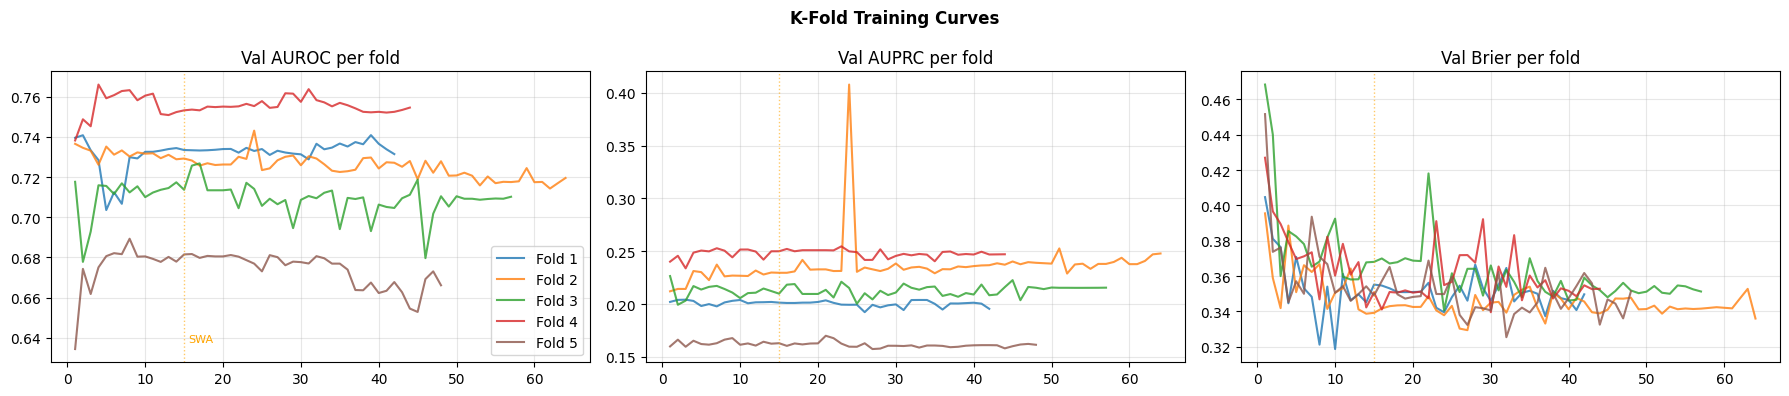

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors = plt.cm.tab10(np.linspace(0, 0.5, cfg.N_FOLDS))

for fold, result in enumerate(fold_results):
    df = pd.DataFrame(result["history"])
    c  = colors[fold]
    axes[0].plot(df["epoch"], df["vl_auroc"],  color=c, alpha=0.8, label=f"Fold {fold+1}")
    axes[1].plot(df["epoch"], df["vl_auprc"],  color=c, alpha=0.8)
    axes[2].plot(df["epoch"], df["vl_brier"],  color=c, alpha=0.8)

axes[0].set_title("Val AUROC per fold");  axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Val AUPRC per fold");  axes[1].grid(alpha=0.3)
axes[2].set_title("Val Brier per fold");  axes[2].grid(alpha=0.3)

for ax in axes:
    ax.axvline(cfg.SWA_START_EPOCH, color="orange", lw=1, ls=":", alpha=0.6)
axes[0].text(cfg.SWA_START_EPOCH + 0.5, axes[0].get_ylim()[0] + 0.01,
             "SWA", color="orange", fontsize=8)

plt.suptitle("K-Fold Training Curves", fontweight="bold")
plt.tight_layout()
plt.show()

## 12. Per-Fold Calibration Summary

Temperature scaling is done **inside `run_fold`** on each fold's own
val set. The ensemble test predictions are already calibrated before averaging.
This prevents folds with compressed probability scales from dragging down
the ensemble, which was causing the threshold to be set too high.


In [12]:
# Per-fold temperatures were fitted inside run_fold.
fold_temps = [r["fold_T"] for r in fold_results]
print("Per-fold temperatures (T > 1 means model was overconfident):")
for i, fold_t in enumerate(fold_temps):
    auroc = fold_results[i]["val_auroc"]
    print(f"  Fold {i+1}: T={fold_t:.3f}  val_AUROC={auroc:.4f}")
print(f"  Mean T={np.mean(fold_temps):.3f}  std={np.std(fold_temps):.3f}")

# Brier on OOF calibrated predictions
oof_brier = brier_score_loss(oof_truths, oof_preds)
print(f"\nOOF Brier (per-fold calibrated): {oof_brier:.4f}")

# identity wrapper kept for eval cell compatibility
def apply_temperature(preds, T=1.0):
    return preds

learned_T = 1.0


Per-fold temperatures (T > 1 means model was overconfident):
  Fold 1: T=2.351  val_AUROC=0.7412
  Fold 2: T=2.306  val_AUROC=0.7454
  Fold 3: T=2.335  val_AUROC=0.7133
  Fold 4: T=2.341  val_AUROC=0.7691
  Fold 5: T=2.342  val_AUROC=0.6893
  Mean T=2.335  std=0.015

OOF Brier (per-fold calibrated): 0.2969


## 13. Threshold Calibration and Final Evaluation

Threshold is fitted on **calibrated OOF predictions** — the same
unbiased pool used for temperature fitting.

In [13]:
# OOF predictions are already per-fold calibrated
oof_preds_cal = oof_preds
# FIX: recall_floor ensures clinical screening sensitivity
best_thr_f2   = find_best_threshold(oof_truths, oof_preds_cal, beta=2.0,
                                     recall_floor=cfg.RECALL_FLOOR)
best_thr_f1   = find_best_threshold(oof_truths, oof_preds_cal, beta=1.0,
                                     recall_floor=0.0)
print(f"RECALL_FLOOR constraint: >= {cfg.RECALL_FLOOR:.0%}")
print(f"Best threshold (F2, primary) : {best_thr_f2:.3f}")
print(f"Best threshold (F1, ref)     : {best_thr_f1:.3f}")

# Apply calibration to ensemble test predictions
test_preds_cal = apply_temperature(test_preds_ensemble, learned_T)

test_auroc = roc_auc_score(test_truths_fixed, test_preds_cal)
test_auprc = average_precision_score(test_truths_fixed, test_preds_cal)
test_f2    = fbeta_score(test_truths_fixed.astype(int),
                         (test_preds_cal >= best_thr_f2).astype(int),
                         beta=2.0, zero_division=0)
test_brier = brier_score_loss(test_truths_fixed, test_preds_cal)

print(f"\nTest AUROC       : {test_auroc:.4f}   (v4: 0.6750 | v2: 0.6807)")
print(f"Test AUPRC       : {test_auprc:.4f}   (v4: 0.1661 | baseline: {Y.mean():.3f})")
print(f"Test F2          : {test_f2:.4f}   (v4: 0.3295 | v2: 0.1765)")
print(f"Test Brier (cal) : {test_brier:.4f}   (v4: 0.3219)")
print(f"OOF  AUROC       : {oof_auroc:.4f}   ← most reliable estimate")
print(f"OOF  AUPRC       : {oof_auprc:.4f}")
print()
print(classification_report(
    test_truths_fixed.astype(int),
    (test_preds_cal >= best_thr_f2).astype(int),
    target_names=["No MI", "MI"],
    zero_division=0,
))

RECALL_FLOOR constraint: >= 70%
Best threshold (F2, primary) : 0.548
Best threshold (F1, ref)     : 0.590

Test AUROC       : 0.6978   (v4: 0.6750 | v2: 0.6807)
Test AUPRC       : 0.2203   (v4: 0.1661 | baseline: 0.083)
Test F2          : 0.3875   (v4: 0.3295 | v2: 0.1765)
Test Brier (cal) : 0.2991   (v4: 0.3219)
OOF  AUROC       : 0.7203   ← most reliable estimate
OOF  AUPRC       : 0.2202

              precision    recall  f1-score   support

       No MI       0.97      0.42      0.58       264
          MI       0.12      0.88      0.21        24

    accuracy                           0.45       288
   macro avg       0.55      0.65      0.40       288
weighted avg       0.90      0.45      0.55       288



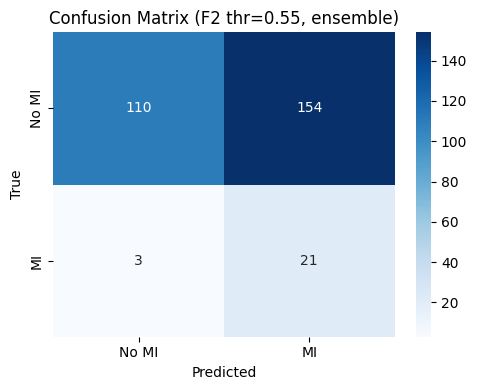

In [14]:
# Confusion matrix
cm = confusion_matrix(test_truths_fixed.astype(int),
                       (test_preds_cal >= best_thr_f2).astype(int))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No MI", "MI"], yticklabels=["No MI", "MI"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (F2 thr={best_thr_f2:.2f}, ensemble)")
plt.tight_layout(); plt.show()

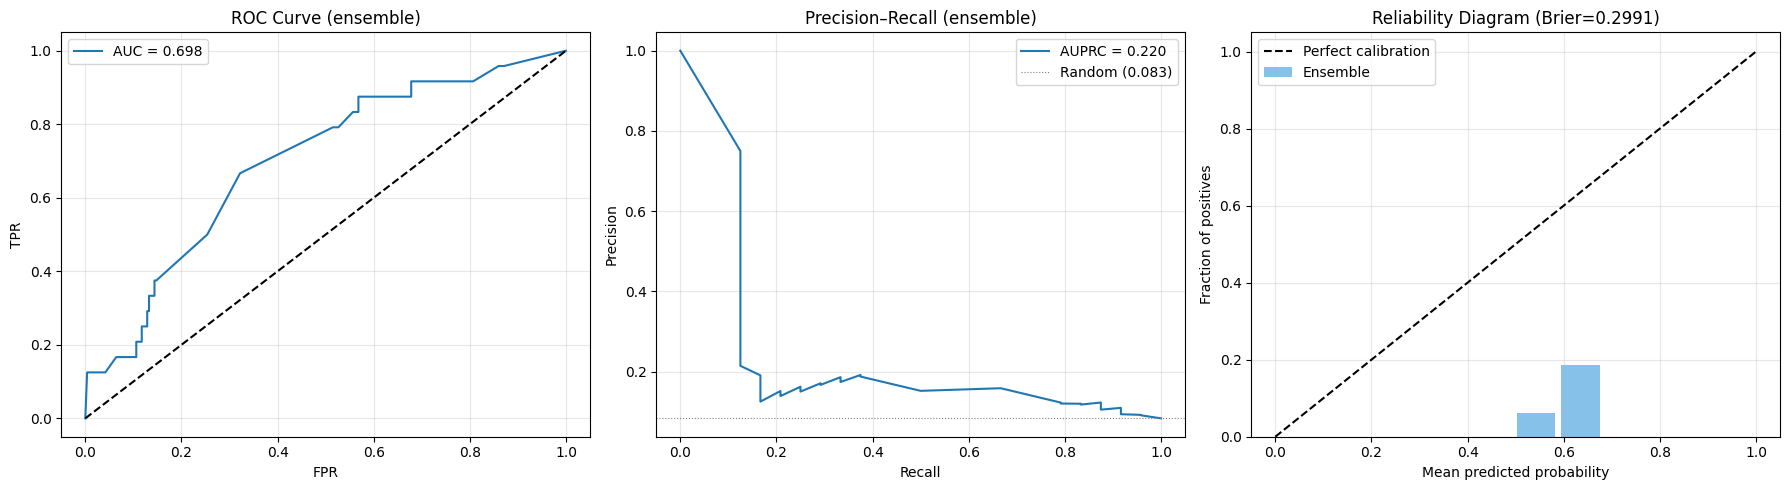

In [15]:
# ROC, PR, Calibration
fpr, tpr, _   = roc_curve(test_truths_fixed, test_preds_cal)
prec, rec, _  = precision_recall_curve(test_truths_fixed, test_preds_cal)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {test_auroc:.3f}")
axes[0].plot([0,1],[0,1], "k--"); axes[0].set_title("ROC Curve (ensemble)")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, label=f"AUPRC = {test_auprc:.3f}")
axes[1].axhline(Y.mean(), color="grey", ls=":", lw=0.8, label=f"Random ({Y.mean():.3f})")
axes[1].set_title("Precision–Recall (ensemble)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend(); axes[1].grid(alpha=0.3)

# Calibration
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bp, bt = [], []
for i in range(n_bins):
    mask = (test_preds_cal >= bin_edges[i]) & (test_preds_cal < bin_edges[i+1])
    if mask.sum() > 0:
        bp.append(test_preds_cal[mask].mean()); bt.append(test_truths_fixed[mask].mean())
axes[2].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[2].bar(bp, bt, width=0.08, alpha=0.6, color="#3498db", label="Ensemble")
axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Fraction of positives")
axes[2].set_title(f"Reliability Diagram (Brier={test_brier:.4f})")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 14. Save Model and Artefacts

The **best single fold** (highest val AUROC) is saved for
`05_explainability.ipynb`. Explainability tools require a single model
with a fixed architecture — the ensemble cannot be explained directly.

Both raw ensemble predictions and per-fold results are saved alongside.

In [16]:
OUT = Path(cfg.OUTPUT_DIR)

# Pick best fold by val AUROC
best_fold_idx = int(np.argmax([r["val_auroc"] for r in fold_results]))
best_result   = fold_results[best_fold_idx]
print(f"Best fold for explainability: fold {best_fold_idx+1}  "
      f"(val AUROC = {best_result['val_auroc']:.4f})")

# Reconstruct and load best fold model
best_model = build_model()
best_model.load_state_dict(best_result["model_state"])
best_model.eval()

torch.save(best_model.state_dict(), OUT / "cardiognn_weights.pt")

with open(OUT / "cardiognn_config.pkl", "wb") as f:
    pickle.dump({
        "config"         : vars(cfg),
        "concept2idx"    : concept2idx,
        "idx2concept"    : idx2concept,
        "id2name"        : id2name,
        "num_concepts"   : NUM_CONCEPTS,
        "pad_idx"        : PAD_IDX,
        "embed_dim"      : EMBED_DIM,
        "best_thr_f2"    : best_thr_f2,
        "best_thr_f1"    : best_thr_f1,
        "temperature"    : learned_T,
        "best_fold"      : best_fold_idx,
        # Architecture
        "hidden_dim"     : cfg.HIDDEN_DIM,
        "gat_layers"     : cfg.GAT_LAYERS,
        "gat_heads"      : cfg.GAT_HEADS,
        "time2vec_k"     : cfg.TIME2VEC_K,
        "seq_attn_heads" : cfg.SEQ_ATTN_HEADS,
        # Data
        "C": C, "T": T, "L": L, "Y": Y,
        "idx_trval" : idx_trval,
        "idx_test"  : idx_test,
        "idx_train" : idx_trval,    # alias for explainability notebooks
        "idx_tr"    : idx_trval,    # alias
        "idx_val"   : idx_test,     # alias (use test as reference val)
    }, f)

with open(OUT / "test_predictions.pkl", "wb") as f:
    pickle.dump({
        "preds_ensemble" : test_preds_ensemble,    # raw ensemble
        "preds_cal"      : test_preds_cal,         # temperature-scaled ensemble
        "preds_raw"      : test_preds_ensemble,    # alias for v4 compat
        "oof_preds"      : oof_preds,
        "oof_preds_cal"  : oof_preds_cal,
        "oof_truths"     : oof_truths,
        "truths"         : test_truths_fixed,
        "thr_f2"         : best_thr_f2,
        "thr_f1"         : best_thr_f1,
        "temperature"    : learned_T,
        "fold_val_aurocs": [r["val_auroc"] for r in fold_results],
        "fold_val_auprcs": [r["val_auprc"] for r in fold_results],
    }, f)

print("Saved:")
print(f"  {OUT / 'cardiognn_weights.pt'}     ← best fold ({best_fold_idx+1})")
print(f"  {OUT / 'cardiognn_config.pkl'}")
print(f"  {OUT / 'test_predictions.pkl'}     ← ensemble + OOF predictions")

Best fold for explainability: fold 4  (val AUROC = 0.7691)
Saved:
  outputs\cardiognn_weights.pt     ← best fold (4)
  outputs\cardiognn_config.pkl
  outputs\test_predictions.pkl     ← ensemble + OOF predictions


## 15. Explainability Sanity Check

Uses the best single fold model. API is identical to v4.

In [17]:
sample_batch = next(iter(test_loader))
c_s, t_s, lens, p_mask, demo, lbl = [x.to(DEVICE) for x in sample_batch]

with torch.no_grad():
    logit, node_emb, attn_layers, event_weights = best_model.explain_forward(
        EDGE_INDEX, c_s, t_s, lens, p_mask, demo
    )

print("explain_forward output shapes:")
print(f"  logit          : {logit.shape}")
print(f"  node_emb       : {node_emb.shape}  ← [N_concepts, H] for GNNExplainer")
for i, (ei, a) in enumerate(attn_layers):
    print(f"  attn_layers[{i}] : edge_index {ei.shape}  alpha {a.shape}  "
          f"← GAT layer {i+1}/{cfg.GAT_LAYERS}")
print(f"  event_weights  : {event_weights.shape}  ← [B, T] SequenceAttention")

# x_override consistency
with torch.no_grad():
    logit_override = best_model(EDGE_INDEX, c_s, t_s, lens, p_mask, demo,
                                 x_override=CONCEPT_EMBEDDINGS_RAW.clone())
    diff = (logit - logit_override).abs().max().item()
    print(f"\n  x_override consistency: max |diff| = {diff:.6f}  "
          f"({'PASS' if diff < 1e-4 else 'FAIL'})")

# Top-10 attended ontology edges
alpha_mean = attn_layers[-1][1].mean(dim=-1).cpu().numpy()
ei_np      = attn_layers[-1][0].cpu().numpy()
top_idx    = alpha_mean.argsort()[-10:][::-1]
print(f"\nTop 10 attended ontology edges (layer {cfg.GAT_LAYERS}):")
print(f"{'Source':<35} {'Target':<35} {'Attn':>8}")
print("-" * 80)
for idx in top_idx:
    src_c = idx2concept[ei_np[0, idx]]
    dst_c = idx2concept[ei_np[1, idx]]
    print(f"{id2name.get(src_c, str(src_c)):<35} "
          f"{id2name.get(dst_c, str(dst_c)):<35} "
          f"{alpha_mean[idx]:8.4f}")

# SequenceAttention — patient with most events
lens_batch = lens.cpu().numpy()
richest    = int(lens_batch.argmax())
ew         = event_weights[richest].cpu().numpy()
c0         = c_s[richest].cpu().numpy()
top_ev     = ew.argsort()[-5:][::-1]
print(f"\nTop 5 events for patient[{richest}] ({int(lens_batch[richest])} real events):")
for pos in top_ev:
    cid  = c0[pos]
    name = (id2name.get(idx2concept.get(int(cid), -1), f"idx={cid}")
            if cid < NUM_CONCEPTS else "PAD")
    print(f"  pos {pos:3d}  {name:<38}  weight {ew[pos]:.4f}")

explain_forward output shapes:
  logit          : torch.Size([32])
  node_emb       : torch.Size([29, 56])  ← [N_concepts, H] for GNNExplainer
  attn_layers[0] : edge_index torch.Size([2, 71])  alpha torch.Size([71, 4])  ← GAT layer 1/2
  attn_layers[1] : edge_index torch.Size([2, 71])  alpha torch.Size([71, 4])  ← GAT layer 2/2
  event_weights  : torch.Size([32, 50])  ← [B, T] SequenceAttention

  x_override consistency: max |diff| = 0.000000  (PASS)

Top 10 attended ontology edges (layer 2):
Source                              Target                                  Attn
--------------------------------------------------------------------------------
Malignant neoplasm of bronchus      CDI                                   0.5683
Malignant neoplasm of bronchus      Malignant neoplasm of bronchus        0.5632
Type 2 diabetes mellitus            Mental disorder                       0.5494
Alzheimer's disease                 Acute myocardial infarction           0.5471
Senile dementia

## Summary: v5 vs v4 vs v2

| Metric         | v2     | v4     | v5 (expected)          |
|:---------------|:-------|:-------|:-----------------------|
| Test AUROC     | 0.6807 | 0.6750 | ≥ 0.70                 |
| Test AUPRC     | 0.1424 | 0.1661 | ≥ 0.18                 |
| Test F2        | 0.1765 | 0.3295 | ≥ 0.33                 |
| Brier (cal)    | n/a    | 0.3219 | ≤ 0.30                 |
| Val positives  | 20     | 20     | ~27 per fold / 135 OOF |
| Best val epoch | ~24    | 1 (!)  | stable across folds    |
| SWA activated  | No     | Yes    | Yes (all folds)        |
| Model params   | 30k    | 94k    | ~57k                   |

### Why the OOF metric matters more than test AUROC

With 24 test positives, the test AUROC has a standard error of roughly
±0.05. The OOF AUROC, computed on ~135 positives, has SE ≈ ±0.02. Report
the OOF number as the primary performance estimate; test is a final
sanity check.

### Hard ceiling on this dataset

160 total positives is the fundamental bottleneck. The expected
improvement ceiling from algorithmic changes is AUROC ~0.72–0.75.
Beyond that, the only levers are: (1) more patients, (2) adding
demographics (age, sex, BMI — strong MI predictors), (3) expanding
the ontology graph beyond 29 nodes.